# E15 · Bayesian additive regression trees: a non-parametric function inside a probabilistic model

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | Capital Bikeshare hourly rentals 2011-2012 (17,379 hours, **subsampled**); LaLonde's job-training data (`nsw` + `cps`) for a causal coda |
| **You will learn** | What the BART prior over functions looks like · `pmb.BART` as a component of an ordinary PyMC model with your own likelihood · how PGBART + NUTS sample it and why you must diagnose in **function space** · what to do (and what not to conclude) when the chains disagree · partial dependence, ICE and variable importance · out-of-sample prediction plumbing in PyMC 6 · an honest comparison with a hand-built GLM · the limits: steps, flat extrapolation, intervals · BART for causal g-computation |

**The idea in plain words.** You do not know the regression function $f(x)$ and you do not
want to choose its form. BART (Chipman, George & McCulloch 2010) writes it as a **sum of many
small regression trees**,

$$ f(x) = \sum_{j=1}^{m} g_j(x), $$

where each tree $g_j$ cuts predictor space into a few boxes and returns one number per box.
A single deep tree would overfit, so the **prior** keeps every tree a *weak learner*: a node
at depth $d$ splits with probability $\alpha(1+d)^{-\beta}$ (defaults 0.95 and 2, so most
trees have two or three leaves), and leaf values are shrunk towards zero with a standard
deviation proportional to $1/\sqrt{m}$, so that no single tree can explain much. Interactions
come for free - a tree that splits on hour and then on working day *is* an interaction - and
the posterior is a distribution over forests, so a flexible function arrives with
uncertainty and almost nothing to tune.

How that differs from the other flexible tools in this repository:

| | you choose | good at | bad at |
|---|---|---|---|
| **Splines** (C03) | which variable bends, how many knots, which interactions exist | smooth 1-D effects, fast NUTS, interpretable coefficients | anything you did not think of |
| **GP / HSGP** (E05, E07) | kernel, lengthscale priors, basis size | smooth functions of 1-3 inputs, honest extrapolation back to the mean | many predictors, discontinuities |
| **BART** (here) | number of trees `m` | many predictors, unknown interactions, mixed types, no scaling needed | smoothness, extrapolation, **sampling** - as we are about to see |

This notebook is deliberately not an advertisement. `pymc-bart` 0.13 (Quiroga et al. 2022),
with its Rust sampler `bartrs`, runs fine under PyMC 6 - and on the main example its chains
do **not** converge in any budget a laptop tutorial can afford. Learning to see that, and to
decide what can still be trusted, is the most useful thing on this page.

In [1]:
import gc
import logging
import time
import warnings

import arviz as az
import bartrs  # the Rust particle-Gibbs sampler behind pymc-bart; importing it registers the PGBART step
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc_bart as pmb
from patsy import build_design_matrices, dmatrix
from scipy import stats
from scipy.special import expit, logsumexp

from pymc_challenges import data

RANDOM_SEED = 15
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

warnings.filterwarnings("ignore", message=".*Numba will use object mode.*")  # BART's random op has no numba version
logging.getLogger("pymc.sampling.forward").setLevel(logging.WARNING)  # silence "Sampling: [f]"

print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, pymc-bart {pmb.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, pymc-bart 0.13.1


## 1 · What does the BART prior say about functions?

With any other model in this repository the answer is one line: `pm.sample_prior_predictive`.
**Not here.** A `pmb.BART` variable has no forward sampler for its prior - until trees have
been fitted, its random draw is the constant `Y.mean()`, so a prior predictive check shows a
flat line and tells you nothing. The tree prior is simple enough to simulate by hand, and
doing so once is the best way to understand it:

1. start with a root node at depth 0;
2. split it with probability $\alpha(1+d)^{-\beta}$; if it splits, pick a predictor and a
   cut point at random and recurse into both children;
3. give every leaf a value from $\text{Normal}(0, \sigma_\mu)$ with
   $\sigma_\mu = \text{sd}(Y)/\sqrt{m}$ (that is what `bartrs` uses), so that the *sum* of
   $m$ trees has about the spread of the data whatever $m$ is.

,alpha,beta,mean leaves per tree,share with <= 3 leaves,max
0,0.95,2.0,2.48,0.88,10
1,0.95,1.0,3.87,0.54,17
2,0.50,2.0,1.62,0.98,6


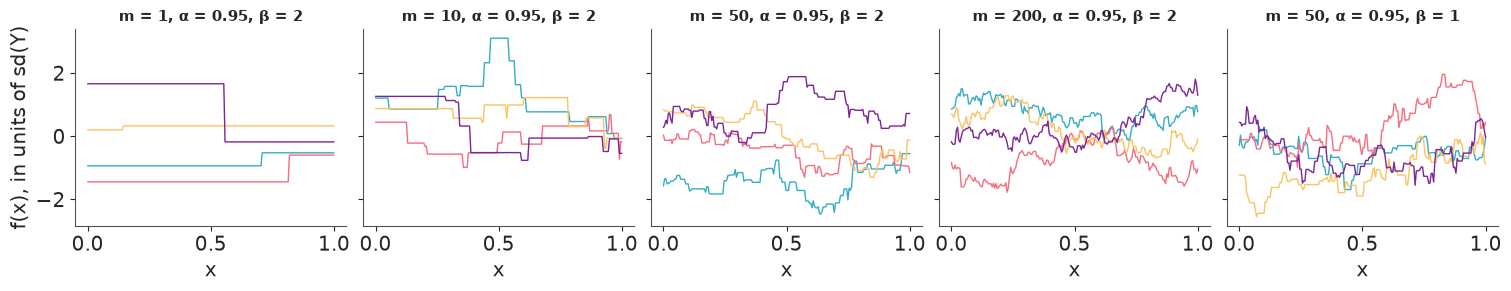

In [2]:
def draw_tree(x, alpha, beta, leaf_sd, rng, depth=0, max_depth=8):
    """One draw from the BART tree prior, evaluated at the 1-D points x."""
    values = np.unique(x)
    if depth < max_depth and len(values) > 1 and rng.random() < alpha * (1 + depth) ** (-beta):
        left = x <= rng.choice(values[:-1])
        out = np.empty(len(x))
        out[left] = draw_tree(x[left], alpha, beta, leaf_sd, rng, depth + 1, max_depth)
        out[~left] = draw_tree(x[~left], alpha, beta, leaf_sd, rng, depth + 1, max_depth)
        return out
    return np.full(len(x), rng.normal(0, leaf_sd))


def draw_forest(x, m, alpha=0.95, beta=2.0, sd_y=1.0, rng=rng):
    return sum(draw_tree(x, alpha, beta, sd_y / np.sqrt(m), rng) for _ in range(m))


def leaves(alpha, beta, rng, depth=0, max_depth=8):
    if depth < max_depth and rng.random() < alpha * (1 + depth) ** (-beta):
        return leaves(alpha, beta, rng, depth + 1) + leaves(alpha, beta, rng, depth + 1)
    return 1


x_grid = np.linspace(0, 1, 200)
settings = [(1, 0.95, 2.0), (10, 0.95, 2.0), (50, 0.95, 2.0), (200, 0.95, 2.0), (50, 0.95, 1.0)]
fig, axes = plt.subplots(1, 5, figsize=(15, 2.8), sharey=True)
for ax, (m, a, b) in zip(axes, settings):
    for _ in range(4):
        ax.plot(x_grid, draw_forest(x_grid, m, a, b), lw=1)
    ax.set_title(f"m = {m}, α = {a}, β = {b:g}", fontsize=11)
    ax.set_xlabel("x")
axes[0].set_ylabel("f(x), in units of sd(Y)")

pd.DataFrame(
    [
        {"alpha": a, "beta": b, "mean leaves per tree": n.mean(), "share with <= 3 leaves": (n <= 3).mean(), "max": n.max()}
        for a, b in [(0.95, 2.0), (0.95, 1.0), (0.5, 2.0)]
        for n in [np.array([leaves(a, b, rng) for _ in range(4000)])]
    ]
).round(2)

- **One tree** is a staircase with a step or two. **Ten** give a rough staircase. **Fifty or
  two hundred** give something that looks like a rough continuous function - but zoom in and
  it is still piecewise constant. The vertical spread is the same in every panel because the
  leaf scale shrinks as $1/\sqrt{m}$: more trees means *finer* steps, not bigger ones.
- With the default $(\alpha, \beta) = (0.95, 2)$ a tree has about 2.5 leaves on average and
  nearly nine in ten have three or fewer: a tree can express a main effect or *one* two-way
  interaction, rarely more. Lowering $\beta$ (last panel) allows deeper trees and a wigglier
  prior.
- There is no lengthscale and no smoothness parameter. The prior does not know that 8 °C is
  close to 9 °C other than through "few splits".

> **Gotcha (pymc-bart 0.13 / bartrs 0.4).** Play with $\beta$ in this simulator, not in the
> model. `bartrs` allocates every tree to a maximum depth of
> $\lfloor(\alpha/0.01)^{1/\beta}\rfloor - 1$: 8 for the defaults, **94 for $\beta = 1$**. A fit
> with `beta=1.0` on 2,000 rows went past 3 GB of memory before the first draw.

## 2 · Data: hourly bike rentals

C03 modelled the *daily* Capital Bikeshare counts with a hand-built negative-binomial GLM.
The hourly file has the same columns plus `hr`, and one structure that dominates everything
else.

In [3]:
data.describe("bike_hour")
raw = data.load("bike_hour")
raw.head(3)

bike_hour: Hourly rental counts 2011-2012 with weather and calendar covariates.
  source: Fanaee-T & Gama (2013), Capital Bikeshare (Washington DC), UCI ML Repository.
  url:    https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


The UCI file stores the weather normalised. For the **hourly** file the documentation gives
temperature as $(t - t_{min})/(t_{max} - t_{min})$ with $t_{min} = -8$, $t_{max} = 39$ °C (the
daily file used in C03 is simply divided by 41), humidity divided by 100 and wind speed by 67.
Weather situation 4 (heavy rain) occurs in three hours out of 17,379; we merge it into 3.

Following C03 we drop the two days of Hurricane Sandy (the system was closed) and hold out
the end of the series: **6 November to 16 December 2012**, six weeks that the models never
see. We stop before Christmas because C03 showed that the holiday fortnight is a different
regime which nothing in these covariates describes.

**Subsampling.** BART's cost grows with rows x trees x iterations, and its sampler runs one
process per chain. We fit on a random **2,000 of the 16,000 training hours**. The models
have no memory between hours, so a random subsample loses precision but not validity. The
hold-out is used in full.

In [4]:
FEATURES = ["hr", "workingday", "temp_c", "hum_pct", "wind_kmh", "weather", "t"]
HOLDOUT = (pd.Timestamp("2012-11-06"), pd.Timestamp("2012-12-17"))
N_TRAIN = 2000

bikes = raw.assign(
    temp_c=raw.temp * 47 - 8,
    hum_pct=raw.hum * 100,
    wind_kmh=raw.windspeed * 67,
    weather=raw.weathersit.clip(upper=3),  # 1 clear, 2 mist, 3 rain or snow
    t=(raw.dteday - pd.Timestamp("2011-01-01")).dt.days / 365.25,  # years since the start
)
bikes = bikes[~bikes.dteday.isin(pd.to_datetime(["2012-10-29", "2012-10-30"]))]
train_all = bikes[bikes.dteday < HOLDOUT[0]]
test = bikes[(bikes.dteday >= HOLDOUT[0]) & (bikes.dteday < HOLDOUT[1])].reset_index(drop=True)
train = train_all.sample(N_TRAIN, random_state=RANDOM_SEED).sort_values("instant").reset_index(drop=True)

print(f"training hours available: {len(train_all):,}; used: {len(train):,}; hold-out hours: {len(test)}")
train[FEATURES + ["cnt"]].describe().round(1)

training hours available: 16,027; used: 2,000; hold-out hours: 982


,hr,workingday,temp_c,hum_pct,wind_kmh,weather,t,cnt
count,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0
mean,11.7,0.7,16.1,62.6,12.6,1.4,0.9,191.5
std,6.9,0.5,9.0,19.3,8.1,0.6,0.5,183.9
min,0.0,0.0,-7.1,0.0,0.0,1.0,0.0,1.0
25%,6.0,0.0,8.9,47.0,7.0,1.0,0.5,43.0
50%,12.0,1.0,17.4,63.0,11.0,1.0,0.9,141.0
75%,18.0,1.0,23.0,79.0,17.0,2.0,1.4,281.0
max,23.0,1.0,36.2,100.0,46.0,3.0,1.8,977.0


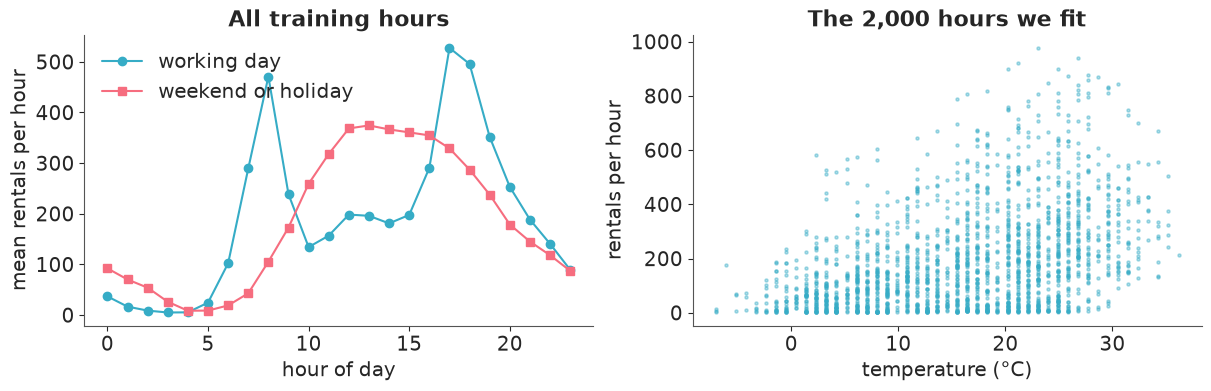

In [5]:
profile = train_all.groupby(["workingday", "hr"]).cnt.mean().unstack(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(profile.index, profile[1], "o-", label="working day")
axes[0].plot(profile.index, profile[0], "s-", color="C1", label="weekend or holiday")
axes[0].set(xlabel="hour of day", ylabel="mean rentals per hour", title="All training hours")
axes[0].legend()
axes[1].scatter(train.temp_c, train.cnt, s=5, alpha=0.4)
axes[1].set(xlabel="temperature (°C)", ylabel="rentals per hour", title="The 2,000 hours we fit");

The left panel is the reason for choosing this dataset. On working days demand has two
commuter spikes (about 470 rentals at 8:00 and over 500 at 17:00) with a trough in between;
at weekends there is a single broad hump in the early afternoon, and 8:00 is quiet. At 8:00
a working day has about 4.5 times the rentals of a weekend day; at 13:00 it has about
*half*. No additive model - "an hour effect plus a working-day effect" - can produce that.
It is an **interaction**, and an analyst building a GLM has to know it is there and write
it down. The question for BART: does it find it without being told?

## 3 · BART as a component of a PyMC model

`pmb.BART` is a random variable like any other, so the likelihood is ours. Counts with
overdispersion and a multiplicative structure call for what C03 used: a negative binomial
with a log link. Only the linear predictor changes:

$$ \text{cnt}_i \sim \text{NegBinomial}(\mu_i, \alpha), \qquad \log \mu_i = f(x_i), \qquad f \sim \text{BART}(m = 50) $$

with $cv = 1/\sqrt{\alpha}$, the hour-to-hour scatter around the expectation as a fraction
of the mean (C03 explains why that is the scale to put a prior on).

Things to know about the call:

- `pmb.BART(name, X, Y, m=...)` wants the response too. `Y` is **not** a second likelihood: it
  sets the starting value and the leaf scale $\text{sd}(Y)/\sqrt{m}$. Pass it on the scale
  of $f$ - here `log(cnt)`.
- Predictors go in raw: no standardising, no dummies, no basis.
- **Tell BART which predictors are categories.** `split_rules` takes one rule per column:
  `"ContinuousSplit"` (is $x \le c$?) or `"OneHotSplit"` (is $x$ equal to this level?); those
  are the only two that `bartrs` 0.4 accepts. This is not a nicety. With the default
  continuous rule, a predictor with many **tied values** - an hour of the day, a 0/1 flag -
  is handled inconsistently between fitting and prediction, and the fit suffers badly.
  Section 6 measures it. We declare `hr`, `workingday` and `weather` as categories. (Hour as
  an unordered category is also what the GLM benchmark will use.)
- Wrap `X` in `pm.Data` **with `dims`** on both axes. Without `dims`, a later
  `pm.set_data(..., coords=...)` cannot resize the `obs` dimension and prediction fails with
  a coordinate-length error.
- **A memory leak to know about.** Every `pmb.BART(...)` call starts a
  `multiprocessing.Manager` server process of 300-500 MB that stores the forests - and
  `del model; gc.collect()` does **not** stop it. This notebook builds nine BART models;
  left alone, that is about 3 GB of idle processes. The `release` helper below shuts the
  manager down through a private attribute (and empties pymc-bart's module-level cache of
  prediction samplers). Afterwards the model can no longer predict, so reduce a fit to the
  numbers and curves you need first.

In [6]:
# categories get "OneHotSplit", everything else "ContinuousSplit"
SPLIT_RULES = ["OneHotSplit" if col in ("hr", "workingday", "weather") else "ContinuousSplit" for col in FEATURES]


def bart_model(df, m=50, split_rules=SPLIT_RULES):
    """Negative-binomial regression with a BART mean on the log scale."""
    with pm.Model(coords={"obs": df.index.values, "feature": FEATURES}) as model:
        X = pm.Data("X", df[FEATURES].to_numpy(float), dims=("obs", "feature"))
        f = pmb.BART("f", X, np.log(df.cnt.values), m=m, split_rules=split_rules, dims="obs")
        cv = pm.HalfNormal("cv", 1.0)
        pm.NegativeBinomial("cnt", mu=pm.math.exp(f), alpha=cv**-2, observed=df.cnt.values, dims="obs", shape=f.shape)
    return model


def fit_bart(df, m=50, tune=1000, draws=500, chains=4, particles=None, split_rules=SPLIT_RULES):
    """Build and sample. Returns (model, idata, seconds). cores=2: one worker PROCESS per running chain."""
    model = bart_model(df, m, split_rules)
    with model:
        step = None if particles is None else [bartrs.PGBART([model["f"]], num_particles=particles)]
        start = time.time()
        idata = pm.sample(draws, tune=tune, chains=chains, cores=2, step=step, random_seed=RANDOM_SEED, progressbar=False)
    return model, idata, time.time() - start


def release(model, name="f"):
    """Free what pmb.BART keeps alive for this model (del + gc do not): the Manager process
    and pymc-bart's module-level cache of prediction samplers, which holds a copy of every stored forest."""
    model[name].owner.op.all_trees._manager.shutdown()
    pmb.utils._posterior_sampler_cache.clear()


model, idata, seconds = fit_bart(train)
print(f"sampling took {seconds:.0f} s; groups: {list(idata.children)}; f is {dict(idata.posterior['f'].sizes)}")

Multiprocess sampling (4 chains in 2 jobs)


CompoundStep


>PGBART: [f]


>NUTS: [cv]


Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 40 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


sampling took 43 s; groups: ['posterior', 'sample_stats', 'observed_data', 'constant_data']; f is {'chain': 4, 'draw': 500, 'obs': 2000}


### How it was sampled

The log says `CompoundStep` with `PGBART: [f]` and `NUTS: [cv]`. Nothing had to be requested:

- Trees are discrete structures with no gradient, so **nutpie is out** - it needs a fully
  continuous, differentiable model. `pm.sample()` notices and falls back to PyMC's own step
  methods. You do *not* need `nuts_sampler="pymc"`.
- `f` is updated by **PGBART**, a particle Gibbs sampler: at each iteration it takes a batch
  of trees (10% of them by default), and for each one grows `num_particles = 10` candidate
  replacements from the prior, weights them by the likelihood of the data given *all other
  trees*, and keeps one. Everything continuous (`cv`) is updated by NUTS given the current
  forest. The two alternate.
- This compound step is a **multiprocess** sampler: every running chain is a separate
  process with its own copy of model, data and forest. Hence `cores=2` - four chains in
  two rounds. With 1,000 + 500 iterations, `f` takes 4 x 500 x 2,000 floats = 32 MB;
  it is the processes, not the arrays, that cost memory.
- To change sampler settings pass the step yourself:
  `pm.sample(step=[bartrs.PGBART([f], num_particles=20, batch=(0.1, 0.1))])`. There is no
  `pmb.PGBART` any more.
- **`random_seed` does not make this reproducible.** With `OneHotSplit` in the model, two runs
  with the same seed give different forests (with the default rule they were identical).
  All BART numbers quoted in the text below are therefore rounded, and where the
  run-to-run variation matters we say so.

We used 500 kept draws rather than the usual 1,000, to stay inside the runtime budget.

## 4 · Diagnose in function space

What would `r_hat` of a tree even mean? Tree structures are not stored in the posterior, and
if they were, tree 17 in chain 1 has no relation to tree 17 in chain 2 - the sum is
identified, the summands are not (the same situation as the weights of the neural network in
E11). So we ask the convergence question about the thing we care about: the value of
$f$ at each observation. That is 2,000 `r_hat`s and 2,000 effective sample sizes;
look at their distribution.

(`pmb.plot_convergence` was the tool for this. In pymc-bart 0.13 it is a **no-op**: the body is a
deprecation warning pointing to `az.plot_convergence_dist`, which is what we use.)

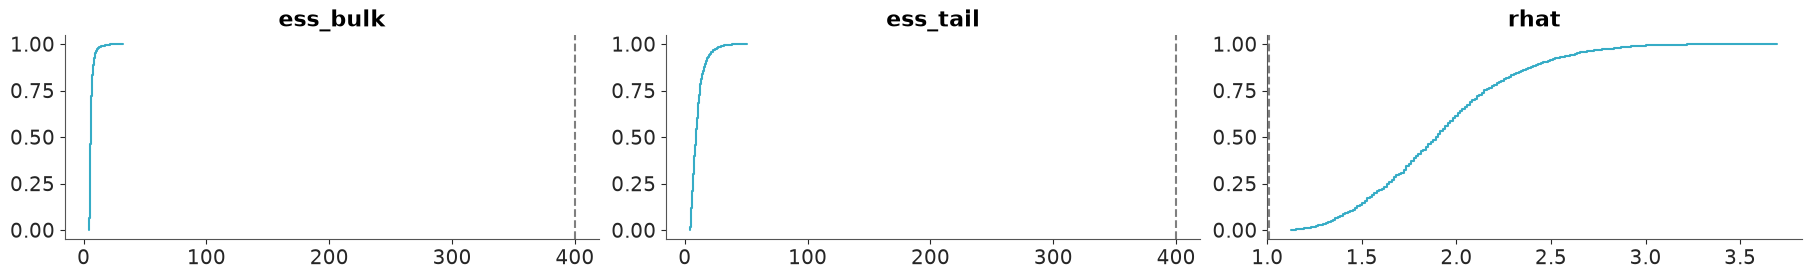

In [7]:
az.plot_convergence_dist(idata, var_names=["f"]);

In [8]:
def per_obs(stat, da):
    """az.rhat / az.ess for every observation of a (chain, draw, obs) array, as a NumPy vector."""
    out = stat(da)
    return (out[da.name] if hasattr(out, "data_vars") else out).values


f_post = idata.posterior["f"]
rhat_f = per_obs(az.rhat, f_post)
ess_f = per_obs(az.ess, f_post)
print(f"r_hat of f(x_i): median {np.median(rhat_f):.2f}, 90th percentile {np.quantile(rhat_f, 0.9):.2f}, "
      f"share below 1.1: {np.mean(rhat_f < 1.1):.1%}")
print(f"bulk ESS of f(x_i) out of {f_post.sizes['chain'] * f_post.sizes['draw']} draws: median {np.median(ess_f):.0f}")
az.summary(idata, var_names=["cv"], round_to=3)

r_hat of f(x_i): median 1.91, 90th percentile 2.46, share below 1.1: 0.0%
bulk ESS of f(x_i) out of 2000 draws: median 6


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
cv,0.438,0.015,0.41,0.459,7.096,10.693,1.544,0.006,0.003


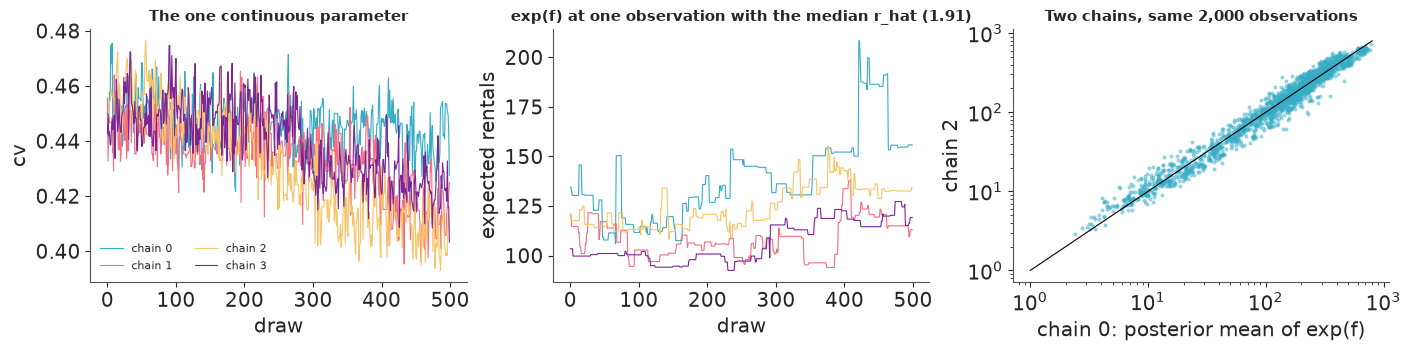

In [9]:
typical = int(np.argsort(rhat_f)[len(rhat_f) // 2])  # the observation with the MEDIAN r_hat: typical, not the worst
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
for c in range(f_post.sizes["chain"]):
    axes[0].plot(idata.posterior["cv"].sel(chain=c), lw=0.8, label=f"chain {c}")
    axes[1].plot(np.exp(f_post.sel(chain=c).isel(obs=typical)), lw=0.8)
axes[0].set(xlabel="draw", ylabel="cv")
axes[0].set_title("The one continuous parameter", fontsize=11)
axes[0].legend(ncols=2, fontsize=8)
axes[1].set(xlabel="draw", ylabel="expected rentals")
axes[1].set_title(f"exp(f) at one observation with the median r_hat ({rhat_f[typical]:.2f})", fontsize=11)
chain_means = np.exp(f_post.mean("draw").values)
axes[2].scatter(chain_means[0], chain_means[2], s=4, alpha=0.4)
axes[2].plot([1, 800], [1, 800], color="k", lw=0.8)
axes[2].set(xscale="log", yscale="log", xlabel="chain 0: posterior mean of exp(f)", ylabel="chain 2")
axes[2].set_title("Two chains, same 2,000 observations", fontsize=11);

In [10]:
within_sd = np.sqrt(np.median(f_post.var("draw").values.mean(axis=0)))
between_sd = np.sqrt(np.median(f_post.mean("draw").values.var(axis=0, ddof=1)))
print(f"typical sd of f within a chain: {within_sd:.3f}; typical sd of the chain means: {between_sd:.3f}  (log scale)")
print("cv by chain:", idata.posterior["cv"].mean("draw").values.round(3))

with model:
    pm.compute_log_likelihood(idata, progressbar=False)  # works with BART: it only needs the draws of f
loo_bart = az.loo(idata, pointwise=True)
print(f"PSIS-LOO, chains pooled: elpd {float(loo_bart.elpd):,.0f}, p_loo {float(loo_bart.p):.0f}, "
      f"Pareto k > 0.7 for {int((loo_bart.pareto_k.values > 0.7).sum())} observations")
for c in range(4):
    loo_c = az.loo(idata.sel(chain=[c]))
    print(f"   chain {c} alone: elpd {float(loo_c.elpd):,.0f}, p_loo {float(loo_c.p):.0f}")

typical sd of f within a chain: 0.086; typical sd of the chain means: 0.120  (log scale)
cv by chain: [0.446 0.434 0.431 0.44 ]


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


PSIS-LOO, chains pooled: elpd -10,689, p_loo 234, Pareto k > 0.7 for 33 observations


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.63 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


   chain 0 alone: elpd -10,632, p_loo 64


...

   chain 1 alone: elpd -10,563, p_loo 63


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.63 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


   chain 2 alone: elpd -10,601, p_loo 118


   chain 3 alone: elpd -10,613, p_loo 77


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.63 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


**This sampler has not converged, and it is not close.**

- Almost none of the 2,000 function values has `r_hat` below 1.1; the median is around 2.
  The effective sample size of a typical $f(x_i)$ is **5 or 6 out of 2,000 draws**.
- The traces show why. Each chain performs a slow random walk around its own level, and
  the levels differ: the chains sit in **different forests** and do not reach each other's
  in 500 draws. `cv` - a perfectly ordinary scalar sampled by NUTS - inherits the problem
  (`r_hat` far above 1.5), because it is conditional on a forest that hardly moves: its
  chain means differ by several hundredths.
- The third panel is the reassuring part: chain by chain the fitted functions agree on the
  big picture (the cloud hugs the diagonal over two orders of magnitude). The disagreement
  is in the detail: the chain means of $f$ typically differ by 0.12 to 0.13 on the log scale
  - about 13% in expected rentals - which is *more* than the 0.07 to 0.085 by which $f$
  varies within a chain.
- **LOO sees it too.** The four chains, scored separately, differ by one to three hundred
  elpd - they are four different models of differing quality. Pooling does not average
  that away: the pooled elpd is no better than a typical single chain, and `p_loo` is
  several times as large. Importance sampling from a mixture of four forests to "the
  posterior without observation $i$" is a long way, and twenty to fifty Pareto-$k$ warnings
  say so. A LOO comparison involving a non-converged BART is a rough guide, not a measurement.

What that means for inference: **a credible interval for $f$ computed from one chain is too
narrow**, because it describes the neighbourhood of one forest, and an interval from the
pooled chains is "spread between four starting points plus within-forest jitter" - better,
but not a posterior. Neither deserves its nominal probability; section 8 checks one against
the truth. Predictive summaries that average over draws are more forgiving, and we will
test those on the hold-out rather than trust them.

Why does this happen here, when BART examples usually show `r_hat` near 1? Particle Gibbs
proposes each replacement tree **from the prior** and lets the likelihood choose among ten
candidates. When the data are noisy, a random two-leaf tree is often about as good as the
current one and the forest keeps turning over. Here the signal is enormous - log-rentals
span seven units with sharp peaks, observed 2,000 times - so nearly every random candidate
loses against the incumbent, and the chain crawls while still far from the best fit.
Section 10 shows the other regime: same sampler, noisy outcome, `r_hat` close to 1.

## 5 · What did the forest learn?

With the caveat of section 4 firmly in mind - these are summaries of four forests that
disagree in detail - the standard tools for opening up a BART fit:

- **Partial dependence** (`pmb.plot_pdp`): the prediction as one predictor varies.
  pymc-bart computes it in its own way, by evaluating the forest with all splits on the
  *other* variables skipped, rather than by averaging predictions over the data; and with
  `func=np.exp` the vertical axis is the exponential of that partial sum - a "typical" level,
  not a mean. Read shapes, not levels. By default the curves are also **smoothed** for
  display (`smooth=True`), which hides the staircase.
- **Individual conditional expectation** (`pmb.plot_ice`): take single observations, vary one
  predictor, keep the others as they are. If the curves are not parallel (on the log scale:
  not proportional), the predictor **interacts** with something.
- Both read the stored forests directly; `samples=` is how many forests they use, and giving
  them a few hundred rows instead of all of them keeps them fast and small. Categories go in
  `var_discrete`, with `xs_interval="insample"` so that they are evaluated at their actual levels.

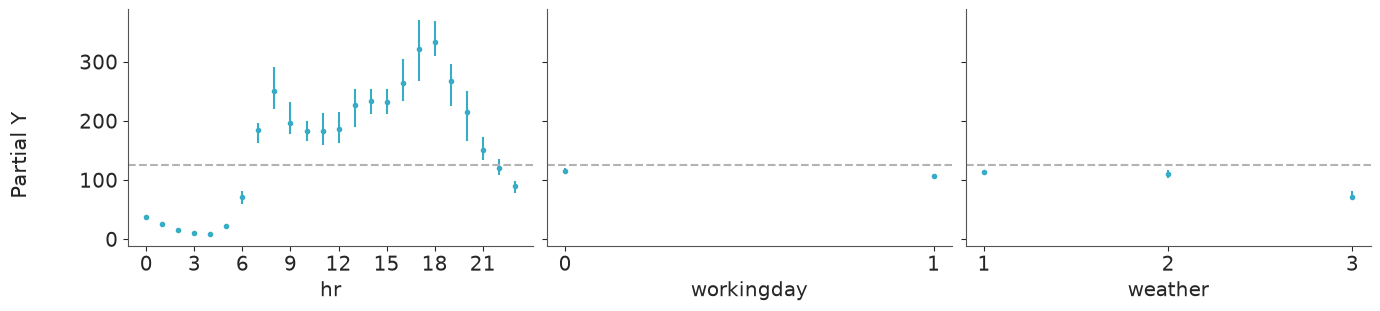

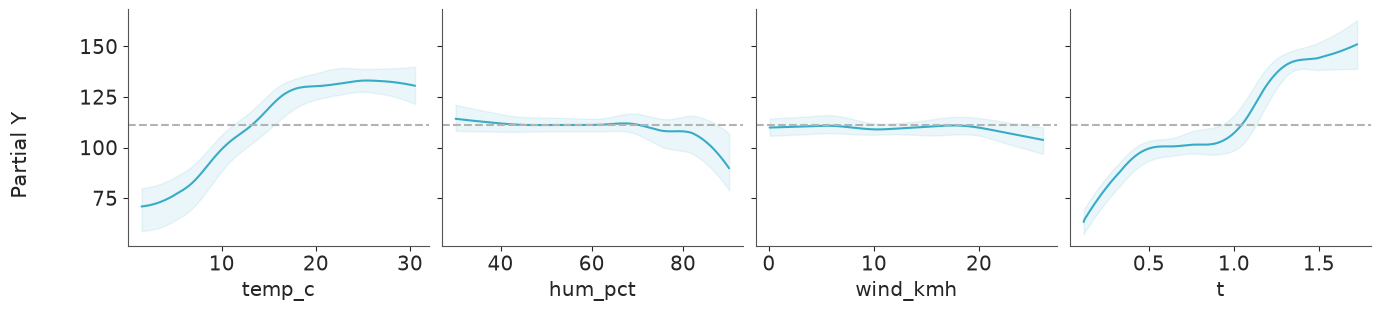

In [11]:
X_sub = train[FEATURES].sample(300, random_state=1)
axes = pmb.plot_pdp(model["f"], X_sub, func=np.exp, samples=100, var_idx=[0, 1, 5], var_discrete=[0, 1, 5],
                    xs_interval="insample", grid="wide", figsize=(13, 3), random_seed=RANDOM_SEED)
axes[0].set_xticks(range(0, 24, 3))
pmb.plot_pdp(model["f"], X_sub, func=np.exp, samples=100, var_idx=[2, 3, 4, 6], grid="wide",
             figsize=(13, 3), random_seed=RANDOM_SEED);

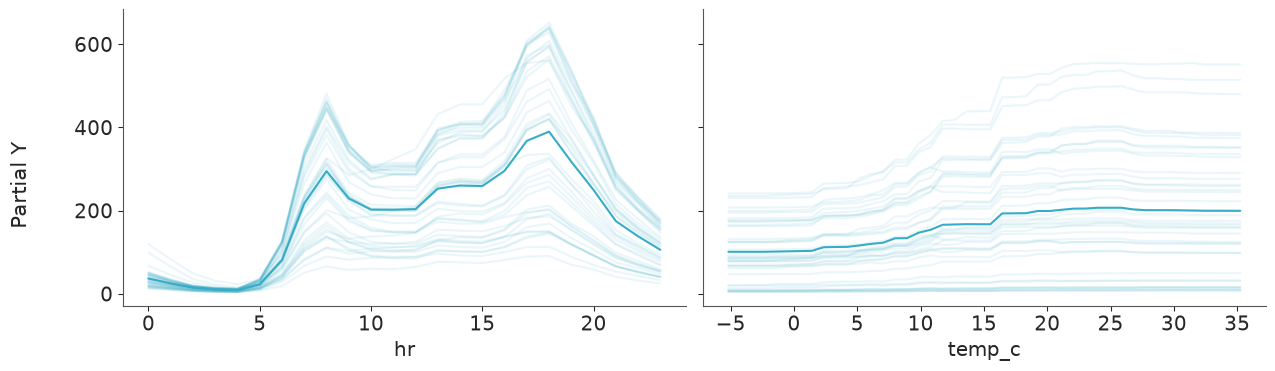

In [12]:
pmb.plot_ice(model["f"], X_sub, func=np.exp, var_idx=[0, 2], centered=False, smooth=False, samples=50,
             instances=40, grid="wide", figsize=(12, 3.6), random_seed=RANDOM_SEED);

Reading the panels:

- **`hr`** dominates: almost nothing at night, a shoulder at 8:00 and the maximum at 17:00-18:00.
  This marginal profile is a blend of two day types - keep that in mind.
- **`workingday`**: both levels sit on the reference line. Taken at face value, working days do
  not matter.
- **`weather`**: rain or snow (3) lowers demand by about a third; mist (2) hardly at all.
- **`temp_c`** rises between roughly 5 and 20 °C and is then flat; high **humidity** costs a
  little; **wind** does nothing; **`t`** shows the growth of the system, about a doubling over
  the two years, with a seasonal wobble, because time is the only predictor that knows the season.
- The **ICE curves for `hr`** are not copies of one curve at different heights. Some have a
  sharp spike at 8:00; others rise smoothly through the morning with no spike at all. That is what
  an interaction looks like in an ICE plot - the effect of the hour depends on something else in
  the row. The **ICE curves for temperature** show the staircase that the smoothed PDP hides:
  flat stretches and a few abrupt jumps, whose positions change from one execution of this
  notebook to the next.

The PDP of `workingday` is the instructive failure: a main-effect summary of a variable that acts
almost entirely *through an interaction* says "nothing here". To see the interaction,
compute the conditional curves ourselves - which is also the general recipe for any what-if
with a fitted BART: build the rows you want, `pm.set_data`, and regenerate `f`.

The plumbing, in PyMC 6.3: after `pm.set_data`, `pm.sample_posterior_predictive` keeps a
variable that is in the trace **frozen at its training values** unless you name it in
`sample_vars=` (you get an `ImplicitFreezeWarning`, and output of the old length). `var_names`
only selects what is returned. So: `sample_vars=["f"]`.

For each hour and day type we take 150 real training rows, overwrite `hr` and `workingday`,
and average the predicted rentals over the rows (a two-way partial dependence). A fifth of
the draws is plenty for a curve.

08:00  working day / weekend: BART 1.51 (94% interval 1.22-2.09), raw means 4.47
13:00  working day / weekend: BART 0.94 (94% interval 0.83-1.02), raw means 0.52
17:00  working day / weekend: BART 1.14 (94% interval 0.89-1.31), raw means 1.60


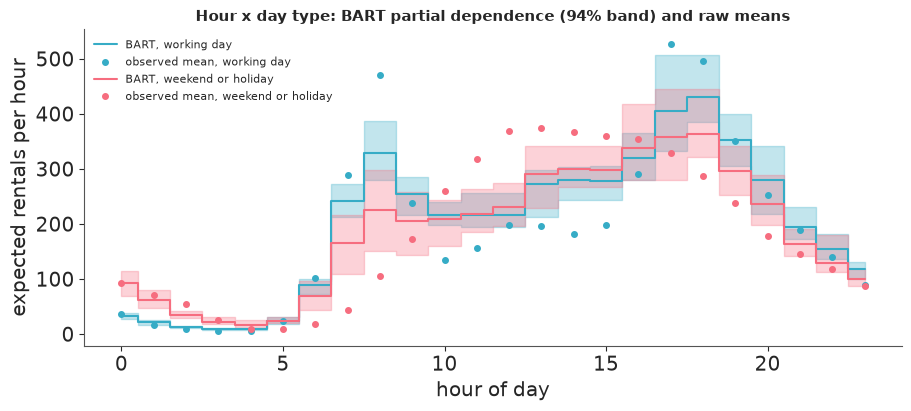

In [13]:
def bart_predict(model, idata, X_new, thin=1):
    """Draws of f for new rows: array (n_new, S). Swap X, then REGENERATE f with sample_vars."""
    with model:
        pm.set_data({"X": np.asarray(X_new, dtype=float)}, coords={"obs": np.arange(len(X_new))})
        pred = pm.sample_posterior_predictive(
            idata.isel(draw=slice(None, None, thin)), sample_vars=["f"], predictions=True,
            random_seed=RANDOM_SEED, progressbar=False,
        )
    return pred.predictions["f"].stack(sample=("chain", "draw")).transpose("obs", "sample").values


rows_pd = train[FEATURES].sample(150, random_state=2).to_numpy(float)
grid = np.concatenate([
    np.column_stack([np.full(len(rows_pd), hr), np.full(len(rows_pd), wd), rows_pd[:, 2:]])
    for wd in (0, 1) for hr in range(24)
])
f_grid = bart_predict(model, idata, grid, thin=5)  # (2 * 24 * 150, draws)
pd_bart = np.exp(f_grid).reshape(2, 24, len(rows_pd), -1).mean(axis=2)  # (day type, hour, draws)

fig, ax = plt.subplots(figsize=(9, 4))
for wd, color, label in [(1, "C0", "working day"), (0, "C1", "weekend or holiday")]:
    lo, hi = np.quantile(pd_bart[wd], [0.03, 0.97], axis=1)
    ax.fill_between(range(24), lo, hi, step="mid", color=color, alpha=0.3)
    ax.step(range(24), pd_bart[wd].mean(axis=1), where="mid", color=color, label=f"BART, {label}")
    ax.plot(profile.index, profile[wd], "o", color=color, ms=4, label=f"observed mean, {label}")
ax.set(xlabel="hour of day", ylabel="expected rentals per hour")
ax.set_title("Hour x day type: BART partial dependence (94% band) and raw means", fontsize=11)
ax.legend(fontsize=8)

ratio = pd_bart[1] / pd_bart[0]
for hr in (8, 13, 17):
    print(f"{hr:02d}:00  working day / weekend: BART {ratio[hr].mean():.2f} (94% interval {np.quantile(ratio[hr], 0.03):.2f}-"
          f"{np.quantile(ratio[hr], 0.97):.2f}), raw means {profile.loc[hr, 1] / profile.loc[hr, 0]:.2f}")

**BART found the interaction without being told** - its morning half, and in shape. On working
days demand jumps at 7:00-8:00 and falls back; at weekends it climbs slowly through the
morning, and weekend nights and middays are busier than working-day ones. The curves cross
in mid-morning, as the raw means do.

**But it is a diluted version.** At 8:00 the raw means say a working day has 4.5 times the
rentals of a weekend day; BART says 1.5 to 2. At 13:00 the truth is about one half; BART says
0.8 to 0.9. And the **evening half is missed**: a working day at 17:00 has 1.6 times the
rentals of a weekend day, and BART gives both day types practically the same evening peak
(a ratio of 1.0 to 1.1 in every execution). Working-day peaks are too low, weekend mornings
far too high (about 200 rentals predicted at 8:00 where about 100 are observed): the fit
is pulled towards the additive model.
(Partial dependence and raw means are not quite the same estimand - the raw means do not hold
weather and season fixed - but hour-by-day-type contrasts are hardly confounded by those.)

The ratio at 8:00 is also the best single illustration of section 4. Three earlier executions
of this notebook, same seed, gave **1.5, 2.0 and 1.6** (the output above is one more), with
94% intervals of ±0.2 to ±0.5. Estimates that move by as much as their interval from one
run to the next do not have posterior intervals.

### Variable importance, with its caveats

pymc-bart offers two measures. **Variable inclusion** counts how often each predictor is
used in a split. `compute_variable_importance` does something more meaningful: it ranks the
predictors by inclusion, then re-predicts with only the top 1, 2, 3, ... of them (splits on
the others are skipped) and reports the $R^2$ between those predictions and the full model's.

,share of splits,R2 with this and all above
hr,0.420,0.836
workingday,0.157,0.850
temp_c,0.105,0.912
t,0.101,0.957
hum_pct,0.088,0.959
weather,0.074,0.969
wind_kmh,0.054,0.966


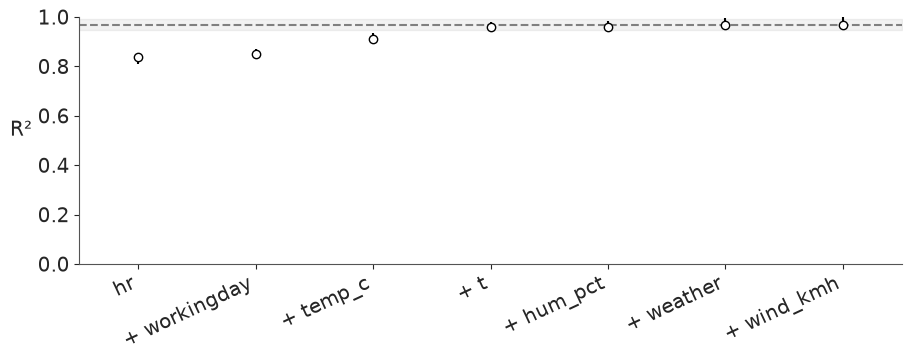

In [14]:
vi = pmb.compute_variable_importance(idata, model["f"], X_sub, method="VI", samples=50, random_seed=RANDOM_SEED)
pmb.plot_variable_importance(vi, figsize=(9, 3.5))
plt.xticks(rotation=25, ha="right")
inclusion, names = pmb.get_variable_inclusion(idata, X_sub)
pd.DataFrame({"share of splits": inclusion, "R2 with this and all above": vi["r2_mean"]}, index=names).round(3)

`hr` takes about 40% of all splits, and a forest reduced to its `hr` splits already reproduces
the full predictions with $R^2 \approx 0.83$. `workingday` is second in splits, yet adding it
moves $R^2$ by only about 0.02; temperature and time bring it to about 0.97, and weather,
humidity and wind add nothing visible.

Caveats, all of which bite here:

- **Split counts reward predictors that are expensive to represent**, not predictors that
  matter. A 24-level category under one-hot splits needs many splits to say anything.
- The $R^2$ is against **the model's own predictions**, not against the truth. It describes this
  forest - and section 4 showed four forests that disagree.
- It is a **main-effect-first** measure. `workingday` looks unimportant because on average over
  the day it *is*: its whole contribution is to change the shape of the hour profile.
- Correlated predictors share the credit arbitrarily: `t` stands in for growth *and* season,
  and season is correlated with temperature and humidity.
- **None of this is causal.** "Importance of `t`" does not mean that waiting causes rentals, and
  the weather effect includes everything that comes with bad weather.

### Collect what we need, then let the forest go

The model object and its Manager process are the most expensive things in this notebook.
Before moving on we take from the forest everything the later sections use - hold-out
predictions and one what-if curve for section 8 - and release it.

In [15]:
alpha_draws, mu_test = {}, {}
alpha_draws["BART, m = 50"] = idata.posterior["cv"].values.ravel() ** -2
mu_test["BART, m = 50"] = np.exp(bart_predict(model, idata, test[FEATURES]))  # (hold-out hours, draws)

temp_grid = np.linspace(-15, 45, 121)
scenario = pd.DataFrame({"hr": 17, "workingday": 1, "temp_c": temp_grid, "hum_pct": train.hum_pct.median(),
                         "wind_kmh": train.wind_kmh.median(), "weather": 1, "t": 1.5})
curve_bart = np.exp(bart_predict(model, idata, scenario[FEATURES]))

release(model)
del model, idata, f_post, f_grid
gc.collect();

## 6 · Can the sampler be helped?

The knobs are few: the number of trees `m`, the length of tuning, the number of particles -
and the split rules. To afford several fits we use a random 1,000 of the 2,000 training
hours and two chains, and judge each fit by

- `cv`: the smaller, the more structure the forest has found (the hand-built GLM of section 7
  will show what is achievable);
- the function-space `r_hat`;
- the **forest gap**: the mean absolute difference between the posterior mean of `f` and the
  stored forests evaluated at *the same training rows*. It should be Monte Carlo noise;
- the log score and mean absolute error on the hold-out (defined in section 7).

Each fit is reduced to one row, released and deleted.

In [16]:
def negbin_draws(mu, alpha, rng):
    """Predictive draws of counts given draws of the mean (n, S) and of alpha (S,)."""
    return rng.negative_binomial(alpha[None, :], alpha[None, :] / (alpha[None, :] + mu))


def holdout_score(mu, alpha, y, rng):
    """Score draws of the expected count, array (n, S), and of alpha (S,), against held-out counts y."""
    logp = stats.nbinom.logpmf(y[:, None], alpha[None, :], alpha[None, :] / (alpha[None, :] + mu))
    lpd = logsumexp(logp, axis=1) - np.log(logp.shape[1])  # log of the posterior-mean predictive density
    q = np.quantile(negbin_draws(mu, alpha, rng), [0.05, 0.25, 0.5, 0.75, 0.95], axis=1)
    return {
        "log score / hour": lpd.mean(),
        "MAE": np.mean(np.abs(q[2] - y)),
        "bias": np.mean(q[2] - y),
        "coverage 50%": np.mean((y >= q[1]) & (y <= q[3])),
        "coverage 90%": np.mean((y >= q[0]) & (y <= q[4])),
    }


def reduce_fit(model, idata, seconds, df):
    alpha = idata.posterior["cv"].values.ravel() ** -2
    score = holdout_score(np.exp(bart_predict(model, idata, test[FEATURES])), alpha, test.cnt.values, rng)
    again = bart_predict(model, idata, df[FEATURES]).mean(axis=1)  # the stored forests at the training rows
    gap = np.abs(idata.posterior["f"].mean(("chain", "draw")).values - again).mean()
    return {"seconds": seconds, "cv": float(idata.posterior["cv"].mean()),
            "median r_hat of f": np.median(per_obs(az.rhat, idata.posterior["f"])), "forest gap": gap,
            "hold-out log score": score["log score / hour"], "hold-out MAE": score["MAE"]}


train_small = train.sample(1000, random_state=RANDOM_SEED).sort_values("instant").reset_index(drop=True)
experiments = {
    "m = 50, tune 1000 (reference)": dict(m=50),
    "m = 20": dict(m=20),
    "m = 100": dict(m=100),
    "m = 50, tune 4000": dict(m=50, tune=4000),
    "m = 50, 20 particles": dict(m=50, particles=20),
    "m = 50, default split rules": dict(m=50, split_rules=None),
}
pymc_logger = logging.getLogger("pymc")
pymc_logger.setLevel(logging.ERROR)  # six sampler logs, all saying "r_hat is large", add nothing
rows = {}
for label, kwargs in experiments.items():
    m_exp, idata_exp, secs = fit_bart(train_small, chains=2, **kwargs)
    rows[label] = reduce_fit(m_exp, idata_exp, secs, train_small)
    release(m_exp)
    del m_exp, idata_exp
    gc.collect()
pymc_logger.setLevel(logging.INFO)

pd.DataFrame(rows).T.round({"seconds": 0, "cv": 3, "median r_hat of f": 2, "forest gap": 3, "hold-out log score": 3, "hold-out MAE": 1})

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,seconds,cv,median r_hat of f,forest gap,hold-out log score,hold-out MAE
"m = 50, tune 1000 (reference)",13.0,0.408,1.52,0.004,-5.497,67.1
m = 20,8.0,0.507,1.57,0.005,-5.586,73.7
m = 100,24.0,0.335,1.30,0.003,-5.383,55.3
"m = 50, tune 4000",35.0,0.356,1.67,0.004,-5.507,66.4
"m = 50, 20 particles",24.0,0.369,1.41,0.004,-5.409,62.5
"m = 50, default split rules",16.0,0.533,1.40,0.162,-5.647,75.2


(These rows are single runs of a sampler that is not reproducible at a fixed seed. Across the
executions made while writing this, the hold-out log score of one and the same one-hot row
moved by 0.1 and more - as much as the differences between rows. Read the table for its
robust features.)

- **The default split rules are broken for tied predictors - and this is the row that is
  perfectly reproducible.** Its forest gap is 0.16 on the log scale - 17% in expected rentals -
  against 0.003 to 0.005 for every fit that declares the categories. In other words: the function the
  likelihood saw while sampling is *not* the function you get back when you ask the stored
  forests about the very same rows. The evidence is behavioural (we have not read the Rust
  source): the gap disappears when the ties are broken by jittering the predictors by ±0.005,
  and it disappears with `OneHotSplit`. It looks as if, during fitting, the continuous rule
  divides tied rows by position rather than by value, so that hours with the same `hr` end up
  on both sides of a split. The cost is large: `cv` of 0.53 instead of about 0.42, and a
  hold-out log score of -5.65 - no better than the additive GLM of the next section. **Run
  this check on every BART fit**; it is one prediction call.
- **Too few trees is the one clear mistake**: `m = 20` is worse on every measure of fit.
- **More trees, longer tuning and more particles all help the fit**: each brings `cv` from
  about 0.41 to the mid 0.3s and improves the hold-out score, at one and a half to three
  times the cost. Which of the three helps most is not something these runs can tell.
- **Nothing helps the mixing.** The median function-space `r_hat` stays between about 1.3 and
  1.9 everywhere. Tuning four times as long does not bring the chains together; it lets each
  one settle more deeply into its own forest.
- None of these budgets reaches what one line of structural knowledge buys (next section):
  `cv` of 0.29.

We keep `m = 50` and 1,000 tuning steps for the main fit because that is what the runtime budget
allows. With time to spare, `m = 100` to `200` and several thousand tuning steps is where to go -
expecting a better fit, not convergence.

## 7 · The parametric benchmark

What would a careful analyst build by hand? C03's daily model, moved to hours: a free effect
for each hour of the day (`ZeroSumNormal`), a working-day shift, a natural cubic spline in
temperature, linear humidity and wind, a weather-situation effect, linear growth in time.
Two versions:

- **additive**: one hour profile shared by all days - the model of someone who has not looked
  at the left panel of the figure in section 2;
- **interaction**: a separate hour profile for working and non-working days - 24 extra
  parameters and one line of code, *if you know to write it*.

These are continuous models, so nutpie samples them (chains as threads in one process).

In [17]:
TEMP_SPLINE = dmatrix("cr(temp_c, df=5, constraints='center') - 1", train)
SCALE = train[["hum_pct", "wind_kmh"]].agg(["mean", "std"])
GLM_PARAMETERS = ["intercept", "hour_eff", "b_work", "w_temp", "b_hum", "b_wind", "weather_eff", "growth", "cv"]


def glm_features(df):
    z = (df[["hum_pct", "wind_kmh"]] - SCALE.loc["mean"]) / SCALE.loc["std"]
    return {
        "B": np.asarray(build_design_matrices([TEMP_SPLINE.design_info], df)[0]),
        "hum": z.hum_pct.values, "wind": z.wind_kmh.values, "hour_idx": df.hr.values,
        "work": df.workingday.values, "weather_idx": df.weather.values - 1, "years": df.t.values - 1.0,
    }


def glm(df, interaction):
    feats = glm_features(df)
    coords = {"obs": df.index.values, "knot": np.arange(feats["B"].shape[1]), "hour": np.arange(24),
              "daytype": ["off", "working"], "weather": ["clear", "mist", "wet"]}
    with pm.Model(coords=coords) as glm_model:
        D = {k: pm.Data(k, v, dims=("obs", "knot") if k == "B" else "obs") for k, v in feats.items()}
        intercept = pm.Normal("intercept", np.log(150), 1)
        if interaction:
            hour_eff = pm.ZeroSumNormal("hour_eff", 1.5, dims=("daytype", "hour"))  # sums to zero over hours
            eta_hour = hour_eff[D["work"], D["hour_idx"]]
        else:
            hour_eff = pm.ZeroSumNormal("hour_eff", 1.5, dims="hour")
            eta_hour = hour_eff[D["hour_idx"]]
        b_work = pm.Normal("b_work", 0, 0.5)
        w_temp = pm.Normal("w_temp", 0, 1, dims="knot")
        b_hum = pm.Normal("b_hum", 0, 0.5)
        b_wind = pm.Normal("b_wind", 0, 0.5)
        weather_eff = pm.ZeroSumNormal("weather_eff", 0.5, dims="weather")
        growth = pm.Normal("growth", 0, 1)
        eta = (intercept + eta_hour + b_work * D["work"] + pm.math.dot(D["B"], w_temp) + b_hum * D["hum"]
               + b_wind * D["wind"] + weather_eff[D["weather_idx"]] + growth * D["years"])
        cv = pm.HalfNormal("cv", 1.0)
        mu = pm.Deterministic("mu", pm.math.exp(eta), dims="obs")
        pm.NegativeBinomial("cnt", mu=mu, alpha=cv**-2, observed=df.cnt.values, dims="obs", shape=mu.shape)
    return glm_model


def glm_predict(glm_model, posterior, df):
    """Draws of the expected count for the rows of df: array (n, S)."""
    with glm_model:
        pm.set_data(glm_features(df), coords={"obs": df.index.values})
        pred = pm.sample_posterior_predictive(posterior, var_names=["mu"], predictions=True,
                                              random_seed=RANDOM_SEED, progressbar=False)
    return pred.predictions["mu"].stack(sample=("chain", "draw")).transpose("obs", "sample").values


loos, scores = {}, {}
for label, interaction in [("GLM additive", False), ("GLM hour x workingday", True)]:
    glm_model = glm(train, interaction)
    start = time.time()
    with glm_model:
        # var_names: do not store `mu`, a 2,000-long deterministic per draw - prediction recomputes it
        glm_idata = pm.sample(var_names=GLM_PARAMETERS, random_seed=RANDOM_SEED, progressbar=False)
        pm.compute_log_likelihood(glm_idata, progressbar=False)
    summary = az.summary(glm_idata, round_to="none")
    print(f"{label}: {time.time() - start:.0f} s, divergences {int(glm_idata.sample_stats['diverging'].sum())}, "
          f"max r_hat {summary.r_hat.max():.3f}, min ESS {summary.ess_bulk.min():.0f}, cv {summary.loc['cv', 'mean']:.3f}")
    loos[label] = az.loo(glm_idata, pointwise=True)
    mu_test[label] = glm_predict(glm_model, glm_idata, test)
    alpha_draws[label] = glm_idata.posterior["cv"].values.ravel() ** -2
    scores[label] = holdout_score(mu_test[label], alpha_draws[label], test.cnt.values, rng)
    if interaction:  # section 8 needs one what-if curve from this model
        curve_glm = glm_predict(glm_model, glm_idata, scenario)
    del glm_model, glm_idata
    gc.collect()

NUTS[nutpie]: [intercept, hour_eff, b_work, w_temp, b_hum, b_wind, weather_eff, growth, cv]


GLM additive: 11 s, divergences 0, max r_hat 1.008, min ESS 733, cv 0.516


NUTS[nutpie]: [intercept, hour_eff, b_work, w_temp, b_hum, b_wind, weather_eff, growth, cv]


GLM hour x workingday: 9 s, divergences 0, max r_hat 1.007, min ESS 392, cv 0.291


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Clean diagnostics, as one expects from a GLM. Note `cv`: about 0.52 without the interaction
and 0.29 with it. One line of structural knowledge removes most of the unexplained scatter.
BART's chains sat at about 0.4.

### LOO

In [18]:
loos["BART, m = 50"] = loo_bart
az.compare(loos, round_to=1)

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
GLM hour x workingday,0,0.0,0.0,NaN,,1 k̂ > 0.70,66.6,-9879.2,69.9,1.0
"BART, m = 50",1,-809.5,46.7,1.0,,33 k̂ > 0.70,233.5,-10688.7,60.7,0.0
GLM additive,2,-1012.9,51.9,1.0,,,35.0,-10892.1,59.7,0.0


The ranking: the GLM **with** the hand-written interaction first, by 650 to 770 elpd over BART
(some fifteen times the `dse`) and about 1,000 over the additive GLM. BART lands in between:
it beats the analyst who did not know about the interaction by 250 to 350 elpd, and loses
clearly to the one who did. Look at `p`: the winning model has an effective 67 parameters;
BART spends 200 to 270 on a worse fit (and that number is inflated by pooling four forests -
see the per-chain values in section 4, and the Pareto-$k$ warnings in the table).

### The hold-out

Six weeks the models never saw, scored three ways: the **log score** per hour (log of the
posterior-mean predictive density; higher is better), the **mean absolute error** of the
predictive median, and the **coverage** of the central 50% and 90% predictive intervals.

One subtlety in the BART plumbing. When `f` is regenerated for new rows, pymc-bart evaluates,
for each posterior draw, a forest picked **at random** from all the stored ones - not the
forest that belongs to that draw. Means and quantiles over draws are unaffected, but draw
number 17 of `f` and draw number 17 of `cv` no longer belong together, and the public API
offers no per-chain predictions. Here it is harmless. It will matter in section 10.

In [19]:
scores["BART, m = 50"] = holdout_score(mu_test["BART, m = 50"], alpha_draws["BART, m = 50"], test.cnt.values, rng)
pd.DataFrame(scores).T.round({"log score / hour": 3, "MAE": 1, "bias": 1, "coverage 50%": 3, "coverage 90%": 3})

,log score / hour,MAE,bias,coverage 50%,coverage 90%
GLM additive,-5.666,74.1,-9.6,0.525,0.882
GLM hour x workingday,-5.306,45.8,5.3,0.538,0.884
"BART, m = 50",-5.517,67.6,-27.5,0.546,0.905


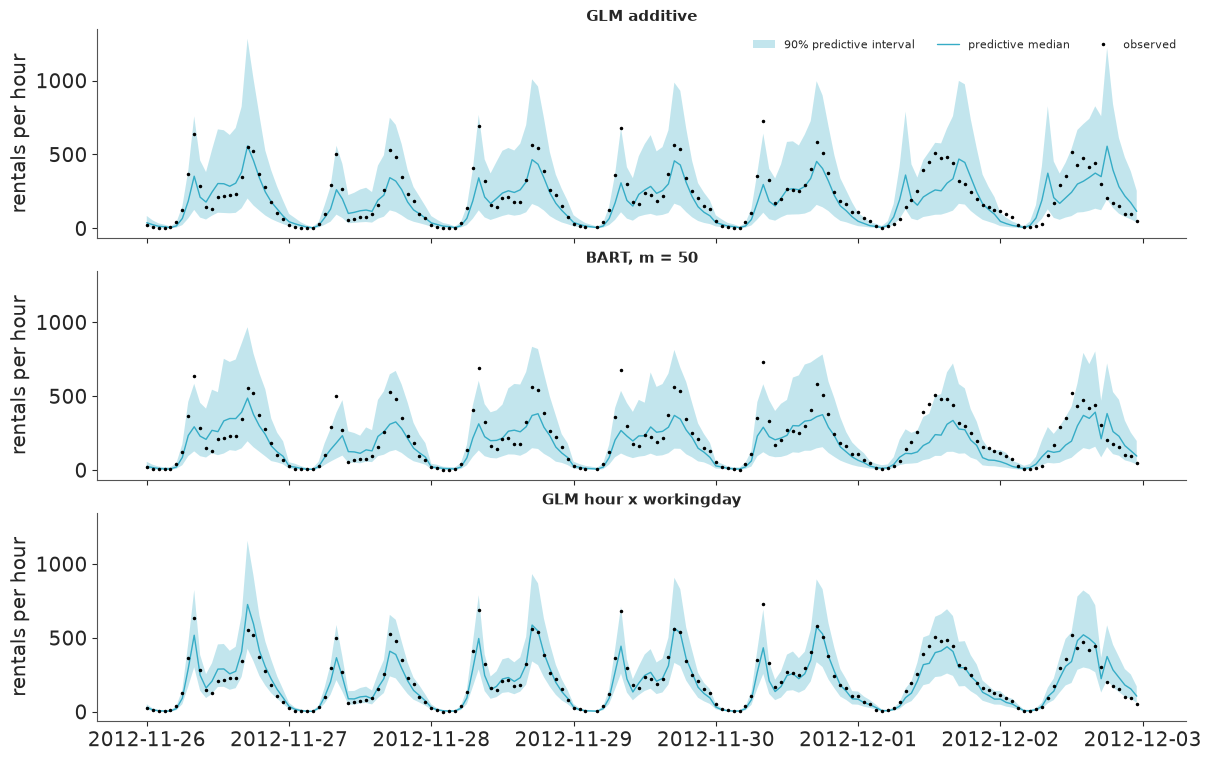

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7.5), sharex=True, sharey=True)
week = (test.dteday >= "2012-11-26") & (test.dteday < "2012-12-03")
when = test.dteday[week] + pd.to_timedelta(test.hr[week], unit="h")
for ax, label in zip(axes, ["GLM additive", "BART, m = 50", "GLM hour x workingday"]):
    q = np.quantile(negbin_draws(mu_test[label][week.values], alpha_draws[label], rng), [0.05, 0.5, 0.95], axis=1)
    ax.fill_between(when, q[0], q[2], alpha=0.3, lw=0, label="90% predictive interval")
    ax.plot(when, q[1], lw=1, label="predictive median")
    ax.plot(when, test.cnt[week], "k.", ms=3, label="observed")
    ax.set(ylabel="rentals per hour")
    ax.set_title(label, fontsize=11)
axes[0].legend(ncols=3, fontsize=8, loc="upper right");

The hold-out agrees with LOO, and because its numbers do not depend on importance sampling
from a non-converged posterior, it is the comparison to believe.

- **BART sits between the two GLMs.** Log score per hour: about -5.67 for the additive GLM,
  **-5.31** for the GLM with the interaction, and around -5.4 to -5.5 for BART over the
  executions of this notebook - roughly half of the way from the naive model to the good one.
  Mean absolute error: 74, **46**, and about 60 to 70.
- **BART under-predicts** by 20 to 40 rentals per hour on average; the GLMs are within 10. The
  hold-out lies *after* the training period and the system kept growing. The GLM's linear
  trend follows it; a tree can only hold the level of its last leaf. This is flat
  extrapolation (section 8) acting in the time dimension, where every forecast needs it.
- **The pooled predictive intervals are calibrated all the same**: the 90% interval covers 88 to
  91% of the hold-out hours and the 50% interval about half, as good as the GLMs. Chains that
  disagree about $f$ by 13% do little harm to a predictive distribution whose spread is
  dominated by negative-binomial scatter of about 40% - and `cv` was estimated *given* the
  under-fitted forests, so it has absorbed their misfit. The figure shows the price:
  BART's band is calibrated but **not sharp** - wide all day long, with a median that blunts the
  commuter spikes (300 to 450 where 500 to 700 rentals occur). The additive GLM draws the same
  day seven times and invents rush hours on Saturday and Sunday. The interaction GLM traces
  both day types, with a much tighter band between the peaks.

So: for zero modelling thought, BART recovered about half of what the right structural insight
was worth, at four to five times the sampling time of the GLM, and without converging.

## 8 · Honest limits, shown on the data

### Steps, and flat extrapolation

The what-if curve we saved in section 5: a working day at 17:00 in clear weather, median
humidity and wind, mid 2012, and only the temperature varies - from -15 °C to 45 °C, well
beyond the -7 to 36 °C of the training sample. The GLM's natural spline continues linearly
(on the log scale) outside its knots.

BART at  -15 °C: mean 285, width of the 94% band 198
BART at   -7 °C: mean 291, width of the 94% band 198
BART at   20 °C: mean 575, width of the 94% band 304
BART at   36 °C: mean 578, width of the 94% band 220
BART at   45 °C: mean 578, width of the 94% band 220
training hours above 33 °C: 22, below -5 °C: 7


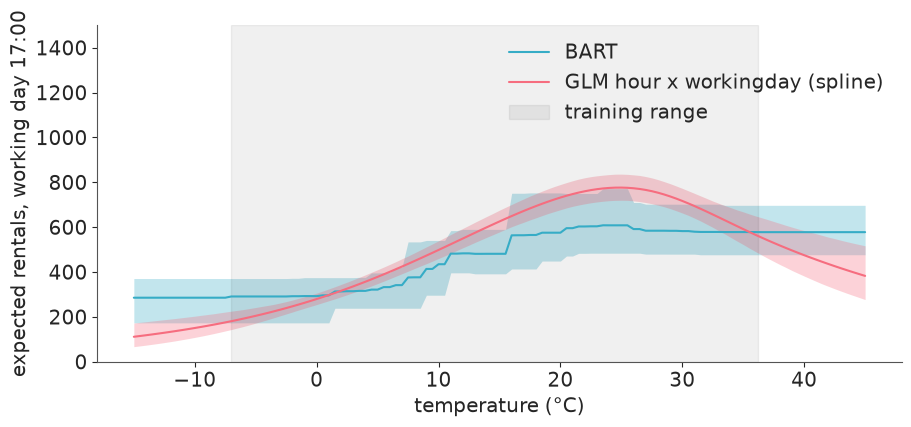

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
for curve, color, label in [(curve_bart, "C0", "BART"), (curve_glm, "C1", "GLM hour x workingday (spline)")]:
    lo, hi = np.quantile(curve, [0.03, 0.97], axis=1)
    ax.fill_between(temp_grid, lo, hi, color=color, alpha=0.3, lw=0)
    ax.plot(temp_grid, curve.mean(axis=1), color=color, label=label)
ax.axvspan(train.temp_c.min(), train.temp_c.max(), color="k", alpha=0.06, label="training range")
ax.set(xlabel="temperature (°C)", ylabel="expected rentals, working day 17:00", ylim=(0, 1500))
ax.legend()

width = np.quantile(curve_bart, 0.97, axis=1) - np.quantile(curve_bart, 0.03, axis=1)
for temp in (-15, -7, 20, 36, 45):
    i = np.abs(temp_grid - temp).argmin()
    print(f"BART at {temp:>4} °C: mean {curve_bart[i].mean():.0f}, width of the 94% band {width[i]:.0f}")
print(f"training hours above 33 °C: {(train.temp_c > 33).sum()}, below -5 °C: {(train.temp_c < -5).sum()}")

- **Outside the data BART is exactly flat**: the prediction at 45 °C is the prediction at 36 °C,
  and -15 °C equals -7 °C. There is no split out there, so there is nothing to change the
  value. Worse, the **band does not widen** either (compare the printed widths): the forest is
  as confident at 45 °C as at the edge of the data. A GP would drift back to its mean with
  growing uncertainty; the spline continues its last slope and fans out. Neither is *right* -
  nobody has seen Washington at 45 °C - but only BART gives no visual hint that it has left
  the data.
- **Inside the data it is a staircase.** "The effect of one more degree" is zero almost
  everywhere and a jump at a handful of split points, whose positions differ between runs.
  Ask a BART fit for the difference between 10 °C and 25 °C, never for a derivative.
- The GLM's curve turns down above about 25 °C - the "too hot to cycle" effect that C03 found in
  the daily data. BART shows little or none of it: with 22 training hours above 33 °C, a prior
  that charges for every split sees no reason to split up there.

### Are the intervals honest where data are sparse?

Two different intervals, two different answers. First the **predictive** intervals on the
hold-out, in corners of predictor space where training rows are few:

In [22]:
y_test = test.cnt.values


def region_masks(df):
    return {
        "all hours": np.ones(len(df), bool),
        "night, 0:00-5:00": (df.hr <= 5).values,
        "working-day rush (7-9, 17-19)": (df.hr.isin([7, 8, 9, 17, 18, 19]) & (df.workingday == 1)).values,
        "weekend 11:00-16:00": ((df.workingday == 0) & df.hr.between(11, 16)).values,
        "rain or snow": (df.weather == 3).values,
        "below 5 °C": (df.temp_c < 5).values,
    }


coverage = {"hold-out hours": {r: int(m.sum()) for r, m in region_masks(test).items()},
            "share of training rows": {r: m.mean() for r, m in region_masks(train).items()}}
for label in ["BART, m = 50", "GLM hour x workingday"]:
    q = np.quantile(negbin_draws(mu_test[label], alpha_draws[label], rng), [0.05, 0.95], axis=1)
    inside = (y_test >= q[0]) & (y_test <= q[1])
    coverage[f"90% coverage, {label}"] = {r: inside[m].mean() for r, m in region_masks(test).items()}
pd.DataFrame(coverage).round(3)

,hold-out hours,share of training rows,"90% coverage, BART, m = 50","90% coverage, GLM hour x workingday"
all hours,982,1.000,0.911,0.883
"night, 0:00-5:00",244,0.234,0.885,0.824
"working-day rush (7-9, 17-19)",162,0.182,0.877,0.907
weekend 11:00-16:00,84,0.076,0.869,0.857
rain or snow,47,0.077,0.851,0.894
below 5 °C,211,0.138,0.853,0.820


Now the **credible** interval for the function itself. For the 48 hour x day-type cells we
have something close to the truth: the raw cell means of all 16,000 training hours, of
which BART saw an eighth. Does BART's 94% band for the partial-dependence curve of
section 5 contain them?

In [23]:
lo, hi = np.quantile(pd_bart, [0.03, 0.97], axis=2)  # (day type, hour)
raw_means = profile[[0, 1]].to_numpy().T  # (day type, hour), all training hours
contains = (raw_means >= lo) & (raw_means <= hi)
print(f"cells whose raw mean lies inside BART's 94% band: {contains.sum()} of {contains.size}")
print(f"working-day 08:00: band {lo[1, 8]:.0f}-{hi[1, 8]:.0f}, raw mean {raw_means[1, 8]:.0f}")
print(f"working-day 17:00: band {lo[1, 17]:.0f}-{hi[1, 17]:.0f}, raw mean {raw_means[1, 17]:.0f}")

cells whose raw mean lies inside BART's 94% band: 18 of 48
working-day 08:00: band 280-387, raw mean 471
working-day 17:00: band 333-507, raw mean 528


- **Predictive intervals: no sign of BART being over-confident in the sparse corners.** In
  rain, in the cold, at night and on weekend middays its 90% intervals cover about as well as
  the GLM's. Both models are weakest at night and in the cold (around 0.82 to 0.86), and that
  is a *likelihood* problem they share - one `cv` for 5 rentals at 4:00 and for 500 at 17:00 -
  not a tree problem. The region where BART is unreliable is not sparse at all: the
  **working-day rush hours**, where coverage ranged from 0.78 to 0.94 over the executions made
  while writing this, against a steady 0.91 for the GLM.
- **Credible intervals for the function: far too narrow.** Only about a third of the 48 raw
  cell means (14 to 19, depending on the run) lie inside BART's 94% band, and the misses are
  systematic: both working-day peaks lie *above* the band. Two things add up here: the prior
  shrinks the forest towards the additive structure, and chains that do not mix under-report
  the spread (section 4).

The often-quoted worry about BART - intervals that are too narrow where data are sparse - shows
up here in the function, not in the predictions.

## 9 · Interlude: what can be trusted?

A non-converged sampler is normally the end of the analysis. With BART on a strong-signal
problem it may be the normal state of affairs, so it pays to be precise about what survived
the checks above and what did not.

| | verdict | evidence |
|---|---|---|
| Point predictions | usable | hold-out error between the two GLMs in every run |
| Pooled **predictive** intervals | usable | 50% and 90% coverage on the hold-out close to nominal, also by region |
| Qualitative structure (which predictors, that hour and day type interact, direction) | usable | the same in every chain and every run |
| **Credible intervals for $f$**, PDP bands, effect sizes such as "the 8:00 ratio" | **not usable** | two thirds of the raw cell means outside the 94% band; the ratio's interval moves by more than its width between runs |
| `cv`, LOO, anything conditional on the forest | rough guide | `r_hat` above 1.5; per-chain elpd spread of a couple of hundred |

The practical rules: always run several chains (one chain would have looked fine); compute
`r_hat` of $f$ at the observations, not of the scalars alone; if it is far from 1, treat the
pooled draws as an **ensemble of fitted forests** - closer to a bagged machine-learning model
than to a posterior - and earn your trust on held-out data; run the forest-gap check; and if
you need intervals for the function itself, this is the wrong tool for this kind of problem.

In [24]:
del mu_test, curve_bart, curve_glm, loos, loo_bart
gc.collect();

## 10 · BART for causal inference: the job-training data again

Hill (2011) proposed BART as the outcome model for causal inference from observational data:
fit $E[Y \mid \text{treat}, X]$ flexibly, then predict every treated unit twice - with
`treat = 1` and with `treat = 0` - and average the difference. That is the **g-computation**
of C09 with the parametric response surface swapped for a forest, so that nobody has to
decide whether earnings are linear in age.

C09 in three numbers: the randomised experiment says training raised 1978 earnings by about
**$1,760**; regression on the participants plus all 15,992 CPS men said about **$70**; and the
same regression on the *trimmed* sample (CPS men with a propensity score of at least 0.05)
said about **$1,030**. We reuse the design: the 185 participants, and as controls either (a)
the trimmed CPS men or (b) a random 2,000 of the CPS (the full 16,000 would work but costs
minutes). The propensity score is only needed for trimming, so a MAP logistic regression
with C09's covariates is enough.

The likelihood is a plain Normal on earnings in $1,000s - crude for an outcome with 30% zeros
(C09 used a hurdle-Gamma), but C09 also showed that a difference in *means* is insensitive to
that choice, and it keeps the focus on the response surface. The 0/1 covariates and `treat`
get `OneHotSplit`.

In [25]:
data.describe("nsw")
nsw, cps = data.load("nsw"), data.load("cps")
COVARIATES = ["age", "educ", "black", "hisp", "marr", "nodegree", "re74", "re75"]
CAUSAL_FEATURES = ["treat"] + COVARIATES
BINARY = ("treat", "black", "hisp", "marr", "nodegree")
CAUSAL_RULES = ["OneHotSplit" if col in BINARY else "ContinuousSplit" for col in CAUSAL_FEATURES]

obs = pd.concat([nsw[nsw.treat == 1], cps], ignore_index=True)
Z = obs[COVARIATES].assign(age=(obs.age - 30) / 10, educ=(obs.educ - 11) / 3, re74=obs.re74 / 1e4, re75=obs.re75 / 1e4)
Z = Z.assign(age2=Z.age**2, u74=(obs.re74 == 0).astype(float), u75=(obs.re75 == 0).astype(float))
with pm.Model() as propensity_model:
    g0 = pm.Normal("g0", 0, 3)
    g = pm.Normal("g", 0, 2, shape=Z.shape[1])
    pm.Bernoulli("treat", logit_p=g0 + pm.math.dot(Z.values, g), observed=obs.treat.values)
    ps_map = pm.find_MAP(progressbar=False)
obs["ps"] = expit(ps_map["g0"] + Z.values @ ps_map["g"])

is_treated = obs.treat == 1
samples = {
    "BART, trimmed CPS (ps >= 0.05)": obs[is_treated | (obs.ps >= 0.05)],
    "BART, random 2,000 CPS men": pd.concat([obs[is_treated], obs[~is_treated].sample(2000, random_state=RANDOM_SEED)]),
}
print(f"CPS men with propensity below 1%: {np.mean(obs.ps[~is_treated] < 0.01):.1%}; "
      f"kept by trimming at 0.05: {int(((obs.ps >= 0.05) & ~is_treated).sum())}")

nsw: Randomised job-training experiment: 185 treated, 260 controls, earnings in 1978.
  source: LaLonde (1986) / Dehejia & Wahba (1999), National Supported Work experiment.
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/causaldata/nsw_mixtape.csv


CPS men with propensity below 1%: 91.4%; kept by trimming at 0.05: 404


Two details in the code below matter more than they look:

- **Both counterfactual worlds go into one prediction call**, stacked into a single matrix of
  2 x 185 rows. Remember that out-of-sample draws use randomly chosen forests: only within
  one call is it certain that the `treat = 1` and the `treat = 0` prediction of a draw come
  from the *same* forest, and that within-draw difference is what the posterior of the
  effect is made of.
- The treated rows' covariates are left exactly as they are. Only the `treat` column changes.

In [26]:
def bart_att(df):
    df = df.reset_index(drop=True)
    y = df.re78.values / 1000
    with pm.Model(coords={"feature": CAUSAL_FEATURES}) as causal_model:
        X = pm.Data("X", df[CAUSAL_FEATURES].to_numpy(float), dims=("obs", "feature"))
        mu = pmb.BART("mu", X, y, m=50, split_rules=CAUSAL_RULES, dims="obs")
        sigma = pm.HalfNormal("sigma", 10)
        pm.Normal("re78", mu, sigma, observed=y, dims="obs", shape=mu.shape)
        start = time.time()
        causal_idata = pm.sample(500, tune=1000, chains=4, cores=2, random_seed=RANDOM_SEED, progressbar=False)
        seconds = time.time() - start
    r = per_obs(az.rhat, causal_idata.posterior["mu"])
    sigma_summary = az.summary(causal_idata, var_names=["sigma"], round_to="none")
    print(f"n = {len(df)}: {seconds:.0f} s; sigma {sigma_summary['mean'].item():.2f} (r_hat {sigma_summary.r_hat.item():.2f}, "
          f"ESS {sigma_summary.ess_bulk.item():.0f}); r_hat of mu(x_i): median {np.median(r):.2f}, 90th pct {np.quantile(r, 0.9):.2f}")

    with causal_model:  # the forest-gap check of section 6: age, educ, re74 and re75 are full of ties
        again = pm.sample_posterior_predictive(causal_idata, sample_vars=["mu"], predictions=True,
                                               random_seed=RANDOM_SEED, progressbar=False).predictions["mu"]
    gap = np.abs(causal_idata.posterior["mu"].mean(("chain", "draw")).values - again.mean(("chain", "draw")).values).mean()
    print(f"    forest gap {gap:.2f}, against a typical posterior sd of mu(x_i) of "
          f"{float(causal_idata.posterior['mu'].std(('chain', 'draw')).median()):.2f}  ($1000s)")

    treated_rows = df.loc[df.treat == 1, CAUSAL_FEATURES].to_numpy(float)
    both = np.vstack([treated_rows, treated_rows])
    both[: len(treated_rows), 0], both[len(treated_rows):, 0] = 1, 0  # do(treat = 1) on top of do(treat = 0)
    with causal_model:
        pm.set_data({"X": both}, coords={"obs": np.arange(len(both))})
        pred = pm.sample_posterior_predictive(causal_idata, sample_vars=["mu"], predictions=True,
                                              random_seed=RANDOM_SEED, progressbar=False)
    mu_cf = pred.predictions["mu"].stack(sample=("chain", "draw")).transpose("sample", "obs").values
    effects = 1000 * (mu_cf[:, : len(treated_rows)] - mu_cf[:, len(treated_rows):])  # (draws, 185) in dollars
    release(causal_model, "mu")
    return effects


def describe(label, att):
    lo, hi = np.quantile(att, [0.03, 0.97])
    return {"analysis": label, "mean": att.mean(), "sd": att.std(), "lo94": lo, "hi94": hi, "P(> $1,000)": np.mean(att > 1000)}


pymc_logger.setLevel(logging.ERROR)
effects = {}
for label, df in samples.items():
    effects[label] = bart_att(df)
    gc.collect()
pymc_logger.setLevel(logging.INFO)

table = pd.DataFrame([describe(label, e.mean(axis=1)) for label, e in effects.items()]).set_index("analysis")
table.loc["C09 experiment (benchmark)", ["mean"]] = 1760
table.loc["C09 regression, trimmed CPS", ["mean"]] = 1030
table.loc["C09 regression, all CPS", ["mean"]] = 70
table.round({"mean": 0, "sd": 0, "lo94": 0, "hi94": 0, "P(> $1,000)": 2})

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


n = 589: 6 s; sigma 6.63 (r_hat 1.00, ESS 596); r_hat of mu(x_i): median 1.02, 90th pct 1.03


    forest gap 0.07, against a typical posterior sd of mu(x_i) of 0.60  ($1000s)


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


n = 2185: 14 s; sigma 6.99 (r_hat 1.00, ESS 885); r_hat of mu(x_i): median 1.14, 90th pct 1.32


    forest gap 0.10, against a typical posterior sd of mu(x_i) of 0.94  ($1000s)


,mean,sd,lo94,hi94,"P(> $1,000)"
analysis,,,,,
"BART, trimmed CPS (ps >= 0.05)",828.0,368.0,154.0,1549.0,0.31
"BART, random 2,000 CPS men",573.0,800.0,-953.0,2143.0,0.29
C09 experiment (benchmark),1760.0,NaN,NaN,NaN,NaN
"C09 regression, trimmed CPS",1030.0,NaN,NaN,NaN,NaN
"C09 regression, all CPS",70.0,NaN,NaN,NaN,NaN


individual posterior means: min 370, median 928, max 1,104
mean effect for the 111 participants without 1975 earnings: 988; for the 74 with: 589
difference: 399, 94% interval -27 to 1,292


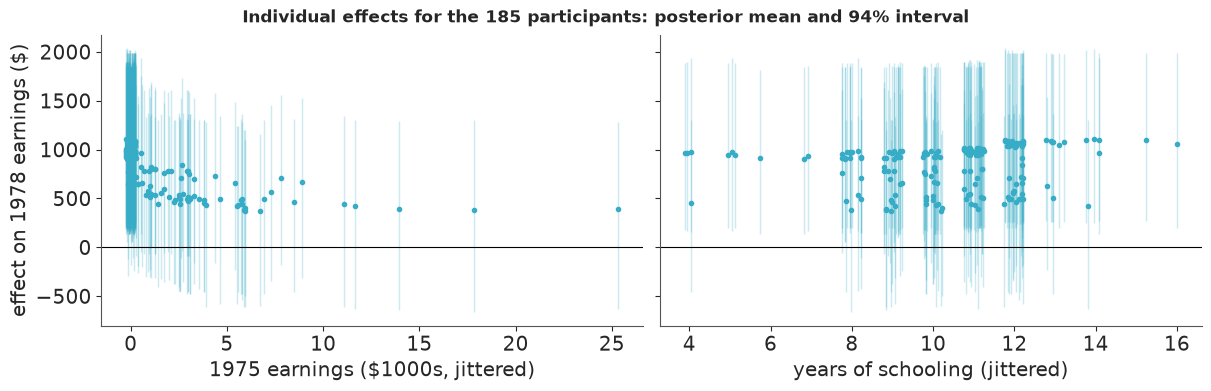

In [27]:
individual = effects["BART, trimmed CPS (ps >= 0.05)"]  # (draws, participants)
participants = samples["BART, trimmed CPS (ps >= 0.05)"].query("treat == 1")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, col, xlabel in [(axes[0], "re75", "1975 earnings ($1000s, jittered)"), (axes[1], "educ", "years of schooling (jittered)")]:
    xv = participants[col].values / (1000 if col == "re75" else 1) + rng.uniform(-0.25, 0.25, len(participants))
    lo, hi = np.quantile(individual, [0.03, 0.97], axis=0)
    ax.vlines(xv, lo, hi, color="C0", alpha=0.25, lw=1)
    ax.plot(xv, individual.mean(axis=0), "o", ms=3, color="C0")
    ax.axhline(0, color="k", lw=0.8)
    ax.set(xlabel=xlabel)
axes[0].set(ylabel="effect on 1978 earnings ($)")
fig.suptitle("Individual effects for the 185 participants: posterior mean and 94% interval", fontsize=12)

means = individual.mean(axis=0)
no_earnings = (participants.re75 == 0).values
print(f"individual posterior means: min {means.min():,.0f}, median {np.median(means):,.0f}, max {means.max():,.0f}")
print(f"mean effect for the {no_earnings.sum()} participants without 1975 earnings: {means[no_earnings].mean():,.0f}; "
      f"for the {(~no_earnings).sum()} with: {means[~no_earnings].mean():,.0f}")
diff = individual[:, no_earnings].mean(axis=1) - individual[:, ~no_earnings].mean(axis=1)
print(f"difference: {diff.mean():,.0f}, 94% interval {np.quantile(diff, 0.03):,.0f} to {np.quantile(diff, 0.97):,.0f}")

**A different regime for the sampler.** Earnings are noisy (residual sd about $6,600 on a
mean of a few thousand), so random candidate trees are competitive and the forest turns over:
on the trimmed sample `r_hat` of $\mu(x_i)$ has a median of 1.01 to 1.02 and `sigma` mixes
like any scalar. On the larger untrimmed sample the chains agree less well (median about 1.2).
The forest gap is not zero here - `age`, `educ` and above all the many zeros of `re74` and
`re75` are tied values under the continuous rule - but it is a tenth to a seventh of the
posterior sd.

**Trimmed sample: about $900.** Over the executions of this notebook the ATT came out between
$760 and $1,000 with a posterior sd of $340 to $440. That is C09's trimmed regression ($1,030)
again, within the noise - and like it, **well short of the experimental $1,760**, which sits
at the very top of the 94% interval or beyond it, depending on the execution. Replacing a hand-built hurdle-Gamma regression with a forest
changed nothing of substance, which is reassuring about C09 and sobering about BART: the
gap to the benchmark was never a functional-form problem. The interval is about half as wide
as C09's; given how BART's prior shrinks towards "no `treat` split", that is not obviously a
virtue.

**Untrimmed: about $600 ± $750** - a 94% interval from somewhere between -$700 and -$1,100 up
to about +$2,000, which contains zero, C09's estimate and the benchmark. (With other subsamples and split rules tried during
development this estimate ranged from about -$140 to +$670.) Compare with C09's regression on
all CPS men: $70 with an sd of $430, *confidently* wrong. The difference is the failure mode. A
participant with no comparable CPS men gets his counterfactual from the leaf he falls into: a
**local average** of the nearest controls there are, held flat - not the value of a line
fitted through 15,000 men who look nothing like him. Here that is the better way to fail. It
is still failing: when the leaf contains no *comparable* men, it averages incomparable ones,
and nothing in the output says so. **BART does not repair a lack of overlap; it changes
linear extrapolation into flat extrapolation.** Overlap diagnostics and trimming (C09, Task 4)
are needed exactly as before.

**Heterogeneity.** The individual effects fall into two bands - around $1,100 to $1,300 for
the 111 participants without 1975 earnings, a few hundred dollars for those with - which is
again a staircase: a split on previous earnings below a split on `treat`. The difference
between the two groups is $500 to $700 with a 94% interval reaching from about zero to
$1,500 - $2,000: suggestive, not established. Every single interval spans two thousand dollars or more, and the
many that exclude zero do so because they share the uncertainty of the *average* effect, not
because anything is known about the individual. BART makes effect heterogeneity cheap to look
at. It does not make 185 treated men enough to estimate it.

## 11 · When would I reach for BART?

**Yes:**

- **As an instrument for criticising a parametric model.** This is the use that paid off on
  this page. Fit the GLM you believe in, fit BART on the same predictors, compare on a
  hold-out. BART beat the additive GLM, which says *something structural is missing*; the ICE
  plot and the conditional curves said *what*; one line in the GLM then beat BART by a wide
  margin. The forest found the interaction; the analyst should own it.
- **Many predictors, unknown interactions, noisy outcome, tabular data** - the regime BART was
  designed for, and the one where PGBART mixes (section 10).
- **As a nuisance model**: the outcome surface in g-computation, a propensity score, an
  imputation model - places where you want flexibility, will average over the function, and do
  not interpret it.
- **With a likelihood that is yours**: counts, censoring, a hierarchical term next to the
  forest. That is the real advantage of `pymc-bart` over a stand-alone BART package.

**No:**

- **You know the structure.** Write it down. It will sample in seconds with `r_hat` of 1.00,
  extrapolate on your terms, and - here - predict much better.
- **Strong signal, sharp features, limited compute.** The sampler crawls, chains disagree, and
  you are left with an ensemble rather than a posterior.
- You need **credible intervals for the function**, smooth effects, derivatives, or any kind of
  **extrapolation** - including forecasting beyond the last observed date.
- You need bit-for-bit **reproducibility**, or have little memory to spare.

**A pymc-bart 0.13 checklist** (each item cost time while writing this): declare categories
with `split_rules` and run the forest-gap check · keep `beta` at 2 or above · `dims` on the
`pm.Data` matrix, `sample_vars=["f"]` when predicting · stack counterfactuals into one
prediction call · `pmb.plot_convergence` does nothing, use `az.plot_convergence_dist` · no
prior predictive for BART, simulate the tree prior yourself · shut down the Manager process of
every model you are done with · `cores=2` · never trust a single chain.

### Try it yourself

1. **Tell it a little.** Refit the bike model with `split_prior=[4, 1, 1, 1, 1, 1, 1]` (four
   times the prior weight on splitting on `hr`). Does it move `cv`, the function-space
   `r_hat`, or the working-day 08:00 peak? Is telling BART where to look still "without
   being told"?
2. **BART for the part you do not know.** Keep the GLM with the hand-written interaction and
   add a BART term on `temp_c`, `hum_pct`, `wind_kmh`, `weather` and `t` only:
   `eta = glm_part + f`. Now the forest has an easier job (a low-amplitude surface) and NUTS
   has 60 parameters to move between forest updates. Do the chains agree better? Does the
   hold-out score beat the pure GLM?
3. **A Bernoulli likelihood.** In section 10, replace the outcome by "had any earnings in
   1978" (`re78 > 0`) with `pm.Bernoulli("y", p=pm.math.sigmoid(mu), ...)` and compute the
   ATT on the probability of working. C09 found that about half of the dollar effect came
   through employment. Does BART agree?